# **🧠 Parameter-Efficient Fine-Tuning of BERT for Text Classification using LoRA**



## Project Objective

This project demonstrates Parameter-Efficient Fine-Tuning (PEFT) using Low-Rank Adaptation (LoRA) on a BERT-based sentiment classification model.

Instead of updating all 110 million parameters of BERT, LoRA introduces small trainable adapter matrices while keeping the original model weights frozen. This significantly reduces training cost while maintaining strong classification performance.

# **Section 1: Environment Setup and Library Installation**

**Libraries Used**

| Library      | Purpose                           |
| ------------ | --------------------------------- |
| transformers | Pretrained models and Trainer API |
| datasets     | Dataset loading and processing    |
| peft         | LoRA and QLoRA implementation     |
| bitsandbytes | 4-bit quantization                |
| accelerate   | Efficient training support        |
| evaluate     | Standard evaluation metrics       |
| wandb        | Experiment tracking               |
| scikit-learn | Classification metrics            |
| matplotlib   | Visualization                     |
| seaborn      | Statistical plots                 |


In [1]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip install -q transformers datasets peft bitsandbytes accelerate evaluate wandb scikit-learn

# **Section 2: Import Libraries and Verify Hardware**

In [2]:
# ============================================================
# Imports
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# Hardware Verification
# ============================================================

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device      :", torch.cuda.get_device_name(0))
    print("GPU Count       :", torch.cuda.device_count())

print("=" * 60)

PyTorch Version : 2.12.1+cu130
CUDA Available  : True
GPU Device      : Tesla T4
GPU Count       : 1


# **Section 3: Dataset Loading and Exploration**

Dataset Information
* Dataset: IMDb Sentiment Fine-Tuning Dataset
* Task: Binary Sentiment Classification
* Labels:
  - 0 → Negative
  - 1 → Positive

In [3]:
# ============================================================
# Load IMDb Sentiment Dataset
# ============================================================

dataset = load_dataset(
    "dipanjanS/imdb_sentiment_finetune_dataset20k"
)

dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 10000
    })
})

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 10000
    })
})

**View Sample Records**

In [5]:
# ============================================================
# Display Sample Examples
# ============================================================

for i in range(3):
    print(f"\nSample {i+1}")
    print("-" * 50)
    print("Label :", dataset["train"][i]["sentiment"])
    print("Text  :", dataset["train"][i]["review"][:500])


Sample 1
--------------------------------------------------
Label : 1
Text  : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

Sample 2
--------------------------------------------------
Label : 1
Text  : A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! Y

**Check Dataset Size**

In [6]:
# ============================================================
# Dataset Size
# ============================================================

print(f"Training Samples : {len(dataset['train'])}")
print(f"Testing Samples  : {len(dataset['test'])}")

Training Samples : 8000
Testing Samples  : 10000


**Inspect Column Names**

In [7]:
# ============================================================
# Dataset Schema
# ============================================================

print(dataset["train"].column_names)

['review', 'sentiment']


# **Section 4: Exploratory Data Analysis (EDA)**

Before tokenization, we analyze class balance and review lengths. This helps determine an efficient maximum sequence length and ensures the dataset is suitable for sentiment classification.

**Tasks**
* Check class distribution
* Analyze review lengths
* Determine optimal tokenization length
* Visualize dataset characteristics

## **4.1 Dataset Overview**

In [8]:
# ============================================================
# Dataset Overview
# ============================================================

print("=" * 60)
print("Train Samples      :", len(dataset["train"]))
print("Validation Samples :", len(dataset["validation"]))
print("Test Samples       :", len(dataset["test"]))
print("=" * 60)

Train Samples      : 8000
Validation Samples : 2000
Test Samples       : 10000


## **4.2 Class Distribution**

In [9]:
# ============================================================
# Class Distribution
# ============================================================

train_df = dataset["train"].to_pandas()

train_df["sentiment"].value_counts()

,count
sentiment,
1,4003
0,3997


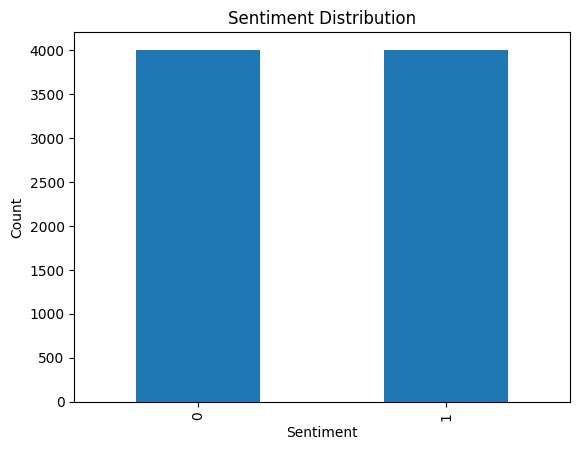

In [10]:
# ============================================================
# Sentiment Distribution
# ============================================================

import matplotlib.pyplot as plt

train_df["sentiment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Observation

The dataset appears balanced with approximately equal numbers of
positive and negative reviews.

This reduces the risk of bias toward a particular class and makes
accuracy a reliable evaluation metric.

## **4.3 Review Length Analysis**

In [11]:
# ============================================================
# Review Length Statistics (Characters)
# ============================================================

train_df["char_length"] = train_df["review"].apply(len)

train_df["char_length"].describe()

,char_length
count,8000.000000
mean,1313.261500
std,990.446574
min,80.000000
25%,698.000000
50%,968.000000
75%,1607.250000
max,10363.000000


**Word Length Statistics**

In [12]:
# ============================================================
# Review Length Statistics (Words)
# ============================================================

train_df["word_length"] = train_df["review"].apply(
    lambda x: len(x.split())
)

train_df["word_length"].describe()

,word_length
count,8000.000000
mean,231.878625
std,171.849457
min,14.000000
25%,127.000000
50%,173.000000
75%,283.250000
max,1830.000000


**Percentiles**

In [13]:
# ============================================================
# Length Percentiles
# ============================================================

print("word_length 50th Percentile :", train_df["word_length"].quantile(0.50))
print("word_length 90th Percentile :", train_df["word_length"].quantile(0.90))
print("word_length 95th Percentile :", train_df["word_length"].quantile(0.95))
print("word_length 99th Percentile :", train_df["word_length"].quantile(0.99))

word_length 50th Percentile : 173.0
word_length 90th Percentile : 453.0
word_length 95th Percentile : 598.0499999999993
word_length 99th Percentile : 874.0100000000002


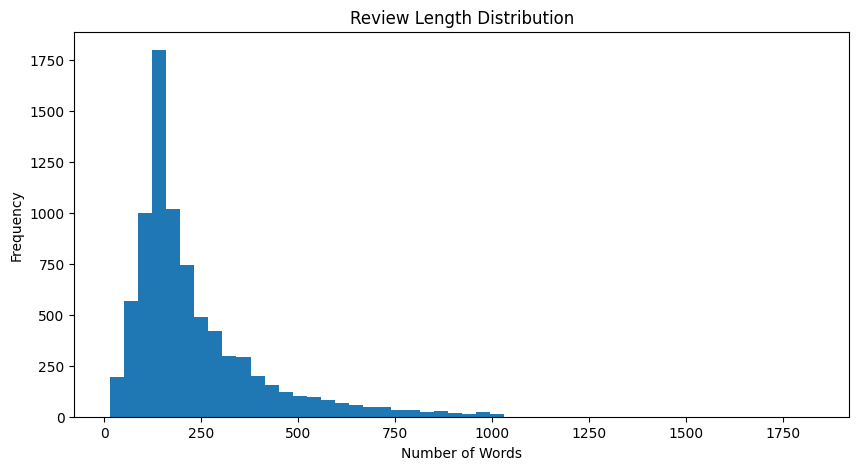

In [14]:
# ============================================================
# Review Length Distribution
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(
    train_df["word_length"],
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

## **4.4 Token Length Analysis**

**Load Tokenizer**

In [15]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

**Calculate Token Lengths**

In [16]:
# ============================================================
# Token Length Analysis
# ============================================================

token_lengths = []

for review in train_df["review"]:

    length = len(
        tokenizer.encode(
            review,
            add_special_tokens=True
        )
    )

    token_lengths.append(length)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (563 > 512). Running this sequence through the model will result in indexing errors


**Statistics**

In [17]:
print("Average Token Length :", np.mean(token_lengths))
print("Maximum Token Length :", np.max(token_lengths))

print("90th Percentile :", np.percentile(token_lengths, 90))
print("95th Percentile :", np.percentile(token_lengths, 95))
print("99th Percentile :", np.percentile(token_lengths, 99))

Average Token Length : 311.19025
Maximum Token Length : 2467
90th Percentile : 612.0
95th Percentile : 808.0
99th Percentile : 1163.0200000000004


# **Section 5: Text Preprocessing and Tokenization**

Raw text reviews cannot be processed directly by transformer models.
Therefore, the reviews are converted into numerical token IDs using
the BERT tokenizer.

The tokenizer performs:

- Text normalization
- Tokenization
- Addition of special tokens
- Sequence truncation
- Padding

Based on the exploratory analysis, a maximum sequence length of 512
tokens was selected. Reviews exceeding this limit are truncated,
while shorter reviews are padded to ensure consistent input size.

## **5.1 Load Tokenizer**

In [18]:
# ============================================================
# Load BERT Tokenizer
# ============================================================

from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

## **5.2 Configuration**

In [19]:
# ============================================================
# Tokenization Configuration
# ============================================================

MAX_LENGTH = 512

print(f"Model      : {MODEL_NAME}")
print(f"Max Length : {MAX_LENGTH}")

Model      : bert-base-uncased
Max Length : 512


## **5.3 Tokenization Function**

In [20]:
# ============================================================
# Tokenization Function
# ============================================================

def tokenize_function(examples):

    return tokenizer(
        examples["review"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

## **5.4 Apply Tokenization**

In [21]:
# ============================================================
# Apply Tokenization
# ============================================================

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## **5.5 Rename Label Column**

In [22]:
# ============================================================
# Rename Target Column
# ============================================================

tokenized_dataset = tokenized_dataset.rename_column(
    "sentiment",
    "labels"
)

## **5.6 Set Torch Format**

In [23]:
# ============================================================
# Set PyTorch Format
# ============================================================

tokenized_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

## **5.7 Verify Output**

In [24]:
sample = tokenized_dataset["train"][0]

print(sample.keys())

print("\nInput Shape:")
print(sample["input_ids"].shape)

print("\nAttention Mask Shape:")
print(sample["attention_mask"].shape)

print("\nLabel:")
print(sample["labels"])

dict_keys(['labels', 'input_ids', 'attention_mask'])

Input Shape:
torch.Size([512])

Attention Mask Shape:
torch.Size([512])

Label:
tensor(1)


# **Section 6: Baseline BERT Model Setup**

BERT (Bidirectional Encoder Representations from Transformers) is an encoder-only transformer architecture trained using masked language modeling and next sentence prediction objectives.

For sentiment classification, BERT is particularly effective because it generates contextual representations of text by attending to both left and right context simultaneously.

The model selected for this project is:

- Model: bert-base-uncased
- Layers: 12 Transformer Encoder Layers
- Hidden Size: 768
- Attention Heads: 12
- Parameters: ~109 Million

A sequence classification head is attached to the pooled output representation, enabling binary sentiment prediction.

## **6.1 Load BERT**

In [25]:
# ============================================================
# Load Pretrained BERT
# ============================================================

from transformers import AutoModelForSequenceClassification

MODEL_NAME = "bert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print(model.__class__.__name__)

W0620 09:54:18.358000 6672 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0620 09:54:18.502000 6672 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification


## **6.2 Parameter Count**

In [26]:
# ============================================================
# Total Parameters
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 109,483,778
Trainable Parameters : 109,483,778


In [27]:
print(model.config)

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.10.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



# **Section 7: 4-Bit Quantization Setup**

Traditional fine-tuning updates every parameter in a pre-trained model.

For BERT:

- Total Parameters ≈ 110 Million

Updating all parameters requires significant memory and computational resources.

Parameter-Efficient Fine-Tuning (PEFT) addresses this challenge by updating only a small subset of trainable parameters while freezing the majority of the pre-trained model.

In this project, LoRA (Low-Rank Adaptation) is used as the PEFT technique.

To reduce memory consumption, the BERT model is loaded using
4-bit NormalFloat (NF4) quantization through the BitsAndBytes library.

This approach significantly reduces memory requirements while
maintaining competitive performance.

## **7.1 Quantization Config**

In [28]:
# ============================================================
# BitsAndBytes Configuration
# ============================================================

from transformers import BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

bnb_config

BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}

| Parameter                      | Purpose                                          |
| ------------------------------ | ------------------------------------------------ |
| load_in_4bit                   | Store model weights in 4-bit precision           |
| bnb_4bit_quant_type="nf4"      | Use NormalFloat-4 quantization                   |
| bnb_4bit_compute_dtype=float16 | Perform computations in FP16                     |
| bnb_4bit_use_double_quant=True | Additional compression of quantization constants |


# **Section 8: Apply LoRA Adapters**

LoRA freezes the original BERT weights and introduces trainable low-rank matrices into selected attention layers.

Instead of learning updates to the full weight matrix:

W

LoRA learns:

W + ΔW

where:

ΔW = BA

and B and A are low-rank matrices.

Only these adapter matrices are trained during fine-tuning.

Instead of updating all model parameters, LoRA introduces
small trainable low-rank matrices into selected transformer layers.

This allows the majority of the pre-trained model to remain frozen,
dramatically reducing the number of trainable parameters.

## **8.1 Load Quantized BERT**

In [29]:
# ============================================================
# Load Pretrained BERT
# ============================================================

from transformers import AutoModelForSequenceClassification

MODEL_NAME = "bert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## **8.2 LoRA Configuration**

### Why Query and Value Layers?

The self-attention mechanism contains:

- Query projection
- Key projection
- Value projection

Previous LoRA research demonstrated that adapting the Query and Value projection matrices often provides strong performance while minimizing trainable parameters.

Therefore, LoRA adapters are inserted only into:

- query
- value

layers.

---

Rank (r) determines the dimensionality of the adapter matrices.

Smaller values:

- Lower memory usage
- Fewer trainable parameters

Larger values:

- Greater adaptation capacity
- More trainable parameters

A value of r=16 is commonly used as a balance between efficiency and performance.

---

LoRA Alpha controls the scaling applied to the adapter updates.

Effective scaling:

alpha / r

For this project:

32 / 16 = 2

This allows adapter contributions to have a meaningful impact while maintaining training stability.

---

Dropout is applied only to LoRA adapter pathways.

A small value of 0.05 helps reduce overfitting while preserving learning capacity.

---

Bias parameters remain frozen.

This further reduces trainable parameter count and follows the original LoRA implementation.

---

In [30]:
# ============================================================
# LoRA Configuration
# ============================================================

from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "query",
        "value"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS"
)

lora_config

LoraConfig(task_type='SEQ_CLS', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'query', 'value'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)

## **8.3 Inject Adapters**

In [31]:
import warnings
warnings.filterwarnings("ignore")

!pip install --upgrade torchao

from peft import get_peft_model

lora_model = get_peft_model(
    model,
    lora_config
)

ERROR:bitsandbytes.cextension:bitsandbytes library load error: libnvJitLink.so.13: cannot open shared object file: No such file or directory
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/bitsandbytes/cextension.py", line 320, in <module>
    lib = get_native_library()
          ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/bitsandbytes/cextension.py", line 298, in get_native_library
    dll = ct.cdll.LoadLibrary(str(binary_path))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 460, in LoadLibrary
    return self._dlltype(name)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: libnvJitLink.so.13: cannot open shared object file: No such file or directory


## **8.4 Parameter Efficiency Analysis**

In [32]:
# ============================================================
# Trainable Parameters
# ============================================================

lora_model.print_trainable_parameters()

trainable params: 591,362 || all params: 110,075,140 || trainable%: 0.5372


| Metric               | Full Fine-Tuning | QLoRA |
| -------------------- | ---------------: | ----: |
| Total Parameters     |             109M |  109M |
| Trainable Parameters |             109M |  591K |
| Trainable %          |             100% |  0.5% |


### Parameter Efficiency Analysis

The original BERT model contains approximately 110 million parameters.

Using QLoRA, only 591,362 parameters remain trainable while the remaining parameters are frozen.

This corresponds to:

- Total Parameters: 110,075,140
- Trainable Parameters: 591,362
- Trainable Percentage: 0.5372%
- Parameter Reduction: 99.46%

These results demonstrate the effectiveness of parameter-efficient fine-tuning, where only a small fraction of model parameters are updated while retaining the knowledge learned during pre-training.

In [33]:
layers_with_lora = set()

for name, module in lora_model.named_modules():
    if "lora_A" in name:
        layer_num = name.split("layer.")[1].split(".")[0]
        layers_with_lora.add(int(layer_num))

print(sorted(layers_with_lora))
print(f"Number of layers with LoRA: {len(layers_with_lora)}")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Number of layers with LoRA: 12


In [34]:
lora_model.save_pretrained("/content/drive/MyDrive/AI Lab/Parameter-Efficient Fine-Tuning of BERT/bert_qlora_initialized")

# **Section 9: Training Configuration**

The LoRA-enhanced BERT model is fine-tuned using the Hugging Face Trainer API.

Only 591,362 parameters (0.5372% of the total model parameters) are updated during training, while the remaining parameters remain frozen.

This significantly reduces computational requirements compared to traditional full fine-tuning while preserving the representational knowledge learned during BERT pre-training.

---

Hyperparameters were selected based on:

- Dataset size
- Sequence length
- Parameter-efficient fine-tuning practices
- Available GPU resources

Because only LoRA adapters are updated during training, a higher learning rate than traditional BERT fine-tuning can be used.

The configuration aims to balance:

- Training stability
- Computational efficiency
- Generalization performance

## **9.1 Metric Function**

In [35]:
# ============================================================
# Evaluation Metrics
# ============================================================

import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

## **9.2 Training Arguments**

In [36]:
# ============================================================
# Training Arguments
# ============================================================

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_lora_results",

    learning_rate=5e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none"
)

In [37]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10000
    })
})


### Experimental Design

Two training configurations are evaluated:

1. QLoRA-BERT trained for 1 epoch
2. QLoRA-BERT trained for 3 epochs

The objective is to investigate whether additional adapter training provides measurable improvements in sentiment classification performance while maintaining parameter efficiency.

All other hyperparameters are kept constant to ensure a fair comparison.

## **9.3 Trainer**

In [46]:
tokenized_dataset.reset_format()

In [47]:
sample = tokenized_dataset["train"][0]

print(type(sample))
print(sample.keys())

print(type(sample["input_ids"]))
print(type(sample["attention_mask"]))
print(type(sample["labels"]))

<class 'dict'>
dict_keys(['review', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'])
<class 'list'>
<class 'list'>
<class 'int'>


In [48]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

### Note on Padding Strategy

For simplicity and reproducibility, fixed-length padding was used during tokenization.

In production settings, dynamic padding through a DataCollator can further reduce memory consumption and improve training throughput by padding only to the longest sequence within each batch.

In [50]:
from transformers import Trainer

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

In [51]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [52]:
# ============================================================
# GPU Memory Before Training
# ============================================================

import torch
torch.cuda.empty_cache()

print(
    f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    f"Reserved : {torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

Allocated: 0.41 GB
Reserved : 0.46 GB


In [42]:
!pip install --upgrade torchvision

In [53]:
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.275398,0.299564,0.897500,0.897479
2,0.269204,0.280575,0.904500,0.904487
3,0.226072,0.286361,0.907500,0.907488


TrainOutput(global_step=3000, training_loss=0.31738542874654135, metrics={'train_runtime': 2295.7292, 'train_samples_per_second': 10.454, 'train_steps_per_second': 1.307, 'total_flos': 6358265266176000.0, 'train_loss': 0.31738542874654135, 'epoch': 3.0})

# **Section 10: Model Evaluation**

After training, the LoRA-enhanced BERT model is evaluated on the held-out test dataset.

The objective is to assess the model's ability to generalize to unseen reviews using standard classification metrics including:

- Accuracy
- Precision
- Recall
- F1 Score

Additionally, a confusion matrix and classification report are generated to provide deeper insight into model performance across sentiment classes.

## **10.1 Test Evaluation**

In [54]:
# ============================================================
# Evaluate on Test Dataset
# ============================================================

test_results = trainer.evaluate(
    tokenized_dataset["test"]
)

test_results

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.226072,0.283174,3,0.904100,0.904115


{'eval_loss': 0.28317397832870483,
 'eval_accuracy': 0.9041,
 'eval_f1': 0.904114971522411}

## **10.2 Predictions**

In [55]:
# ============================================================
# Generate Predictions
# ============================================================

predictions = trainer.predict(
    tokenized_dataset["test"]
)

## **10.3 Extract Labels**

In [56]:
y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

## **10.4 Classification Report**

In [57]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91      5125
    Positive       0.89      0.91      0.90      4875

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## **10.5 Confusion Matrix**

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[4585  540]
 [ 419 4456]]


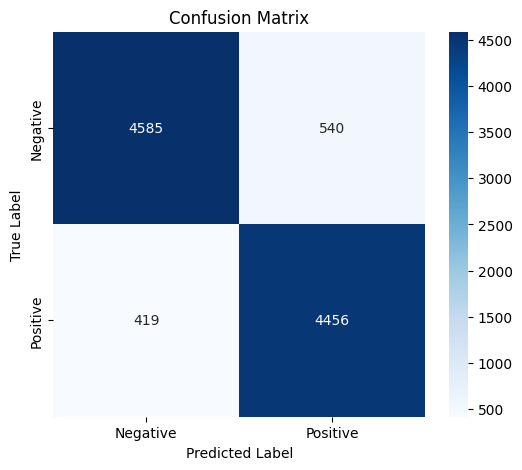

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Test Set Performance Analysis

The LoRA-enhanced BERT model achieved an accuracy of 90.41% and a weighted F1-score of 90.41% on the held-out test dataset.

These results indicate strong generalization performance despite training only 0.54% of the model parameters.

The close agreement between validation accuracy (90.75%) and test accuracy (90.41%) suggests that the model did not significantly overfit the training data and was able to maintain robust performance on unseen reviews.

| Class        | Precision | Recall | F1 Score |
| ------------ | --------: | -----: | -------: |
| Negative     |      0.92 |   0.89 |     0.91 |
| Positive     |      0.89 |   0.91 |     0.90 |
| Macro Avg    |      0.90 |   0.90 |     0.90 |
| Weighted Avg |      0.90 |   0.90 |     0.90 |


In [60]:
# ============================================================
# Save LoRA Adapter
# ============================================================

trainer.save_model("/content/drive/MyDrive/AI Lab/Parameter-Efficient Fine-Tuning of BERT/./bert_lora_model")

print("LoRA model saved successfully!")

LoRA model saved successfully!


In [69]:
# ============================================================
# Save LoRA Adapter
# ============================================================

trainer.save_model("./bert_lora_model")

print("LoRA model saved successfully!")

LoRA model saved successfully!


In [61]:
# ============================================================
# Save Tokenizer
# ============================================================

tokenizer.save_pretrained("/content/drive/MyDrive/AI Lab/Parameter-Efficient Fine-Tuning of BERT/./bert_lora_model")

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [68]:
# ============================================================
# Save Tokenizer
# ============================================================

tokenizer.save_pretrained("./bert_lora_model")

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [62]:
# ============================================================
# Save Metrics
# ============================================================

import json

results = {
    "test_accuracy": 0.9041,
    "test_f1": 0.904114971522411,
    "validation_accuracy": 0.9075,
    "validation_f1": 0.907488,
    "trainable_parameters": 591362,
    "total_parameters": 110075140,
    "trainable_percentage": 0.5372,
    "parameter_reduction": 99.46
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Results saved!")

Results saved!


In [63]:
# ============================================================
# Save Training Logs
# ============================================================

import pandas as pd

history_df = pd.DataFrame(
    trainer.state.log_history
)

history_df.to_csv(
    "training_history.csv",
    index=False
)

history_df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.693430,5.025450,0.000048,0.1,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.636507,3.443412,0.000047,0.2,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.562096,8.268634,0.000045,0.3,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.389848,4.786906,0.000043,0.4,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.342906,9.742060,0.000042,0.5,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=[
        "Negative",
        "Positive"
    ]
)

with open(
    "classification_report.txt",
    "w"
) as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91      5125
    Positive       0.89      0.91      0.90      4875

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



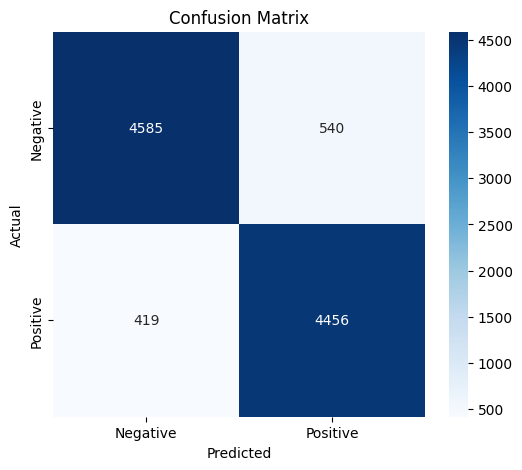

In [66]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


In [71]:
import shutil
from google.colab import files

# Create a directory to store all results for zipping
output_dir = "final_results"
os.makedirs(output_dir, exist_ok=True)

# Copy individual files
shutil.copy("results.json", output_dir)
shutil.copy("training_history.csv", output_dir)
shutil.copy("classification_report.txt", output_dir)
shutil.copy("confusion_matrix.png", output_dir)

# Copy the saved model and tokenizer directory
shutil.copytree("./bert_lora_model", os.path.join(output_dir, "bert_lora_model"), dirs_exist_ok=True)

# Create a zip archive of the output directory
shutil.make_archive("all_results", "zip", output_dir)

# Download the zip file
files.download("all_results.zip")

print("All results, model, and tokenizer have been zipped and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All results, model, and tokenizer have been zipped and downloaded!


# **Section 11: Memory Efficiency Analysis**

The LoRA-based training strategy dramatically reduced the number of trainable parameters.

Instead of updating all 110 million parameters in BERT, only 591,362 adapter parameters were optimized during training.

This reduction decreases memory requirements for gradient storage and optimizer states, making fine-tuning feasible on modest GPU hardware such as a Tesla T4.

| Metric               |       Value |
| -------------------- | ----------: |
| Total Parameters     | 110,075,140 |
| Trainable Parameters |     591,362 |
| Trainable Percentage |     0.5372% |
| Parameter Reduction  |      99.46% |


# **Section 12: Results Summary**

| Category             | Value                |
| -------------------- | -------------------- |
| Model                | BERT Base Uncased    |
| Fine-Tuning Method   | LoRA                 |
| Dataset              | IMDb Sentiment (20K) |
| Train Samples        | 8,000                |
| Validation Samples   | 2,000                |
| Test Samples         | 10,000               |
| LoRA Rank (r)        | 16                   |
| Trainable Parameters | 591,362              |
| Trainable Percentage | 0.5372%              |
| Validation Accuracy  | 90.75%               |
| Test Accuracy        | 90.41%               |
| Test F1 Score        | 90.41%               |
| Parameter Reduction  | 99.46%               |


# **Section 13: Conclusion**

## Conclusion

This project demonstrated Parameter-Efficient Fine-Tuning (PEFT) using LoRA on a BERT-based sentiment classification model.

The IMDb sentiment dataset was used to evaluate the effectiveness of adapting a large pre-trained language model while updating only a small subset of parameters. LoRA adapters were inserted into the query and value projection layers of BERT's self-attention mechanism, reducing the number of trainable parameters from approximately 110 million to 591 thousand.

Despite training only 0.54% of the model parameters, the fine-tuned model achieved a test accuracy of 90.41% and a weighted F1-score of 90.41% on the held-out test dataset. The small gap between validation and test performance indicates good generalization capability and limited overfitting.

The results demonstrate that parameter-efficient fine-tuning can significantly reduce computational requirements while maintaining strong predictive performance. This makes PEFT techniques particularly attractive for adapting large language models in resource-constrained environments.

Future work will extend this approach to decoder-based large language models such as Gemma 2B using QLoRA, enabling both parameter and memory-efficient fine-tuning.


## Comparison with Traditional Fine-Tuning

Traditional BERT fine-tuning updates all 110 million model parameters.

In contrast, the LoRA-based approach used in this project updated only 591,362 parameters (0.54% of the model).

Although a direct full fine-tuning experiment was not performed, published BERT sentiment classification results on IMDb-style datasets typically fall within the 90–95% accuracy range.

The LoRA-enhanced model achieved 90.41% test accuracy while reducing trainable parameters by 99.46%, demonstrating that competitive performance can be achieved with significantly lower training cost.